# Garbage Classification — End-to-End ML Cycle

This notebook covers the offline half of the ML Cycle assignment: data acquisition,
preprocessing, model creation (MobileNetV2 transfer learning), evaluation, and a
reusable retraining function. The API/UI/deployment/load-testing pieces live outside
this notebook in `src/`, `api/`, `ui/`, and `locust/`.

**Dataset:** [Garbage Classification](https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification)
— 6 classes: cardboard, glass, metal, paper, plastic, trash.


## 1. Setup

In [3]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, precision_recall_fscore_support
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"          # original downloaded dataset, one folder per class
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]


ModuleNotFoundError: No module named 'tensorflow'

## 2. Data Acquisition

Two options are provided — use whichever is available in your environment.
Only one needs to run.


In [6]:
# Option A: Kaggle API (Downloads via kagglehub)
!pip install kagglehub -q
import kagglehub
from pathlib import Path

# Download the dataset
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")
print("Downloaded to:", path)

# The dataset structure from Kaggle usually has a nested folder
# We point RAW_DIR to the folder containing the actual class subfolders
RAW_DIR = Path(path) / "Garbage classification" / "Garbage classification"

Using Colab cache for faster access to the 'garbage-classification' dataset.
Downloaded to: /kaggle/input/garbage-classification


In [8]:
# Verify the path exists and list image counts
if not RAW_DIR.exists():
    # Fallback in case folder structure is different
    RAW_DIR = Path(path)

assert RAW_DIR.exists(), f"RAW_DIR not found at {RAW_DIR}"

print(f"Reading data from: {RAW_DIR}")
for cls in CLASS_NAMES:
    n = len(list((RAW_DIR / cls).glob("*")))
    print(f"{cls:10s}: {n} images")

Reading data from: /kaggle/input/garbage-classification/Garbage classification/Garbage classification
cardboard : 403 images
glass     : 501 images
metal     : 410 images
paper     : 594 images
plastic   : 482 images
trash     : 137 images


## 3. Exploratory Data Analysis & Feature Interpretation

Three interpretable "features" of this dataset and what they tell us:

1. **Class balance** — is the dataset skewed toward any material type? An imbalanced
   dataset needs class weighting or augmentation, otherwise the model will be biased
   toward majority classes.
2. **Image brightness distribution per class** — glass/metal tend to be reflective and
   brighter on average than cardboard/paper, which can be a genuinely predictive
   low-level cue the model may latch onto.
3. **Image size/aspect-ratio distribution** — inconsistent source image sizes tell us
   how aggressive our resizing/cropping strategy needs to be, and whether certain
   classes were photographed under more standardized conditions than others.


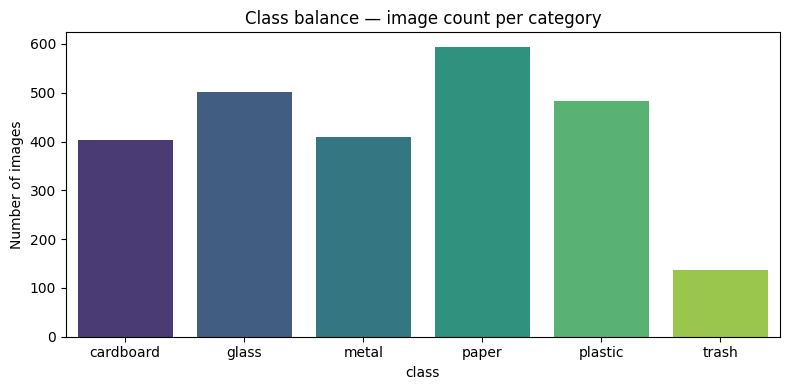

       class  count
0  cardboard    403
1      glass    501
2      metal    410
3      paper    594
4    plastic    482
5      trash    137

Interpretation: classes differ in count by up to 457 images — moderate imbalance, worth using class_weight during training.


In [9]:
# Feature 1: class balance
counts = {cls: len(list((RAW_DIR / cls).glob("*"))) for cls in CLASS_NAMES}
counts_df = pd.DataFrame(list(counts.items()), columns=["class", "count"])

plt.figure(figsize=(8, 4))
sns.barplot(data=counts_df, x="class", y="count", hue="class", palette="viridis", legend=False)
plt.title("Class balance — image count per category")
plt.ylabel("Number of images")
plt.tight_layout()
    plt.savefig("data/visualizations/class_balance.png")
plt.show()

print(counts_df)
print("\nInterpretation: classes differ in count by up to "
      f"{counts_df['count'].max() - counts_df['count'].min()} images — "
      "moderate imbalance, worth using class_weight during training.")


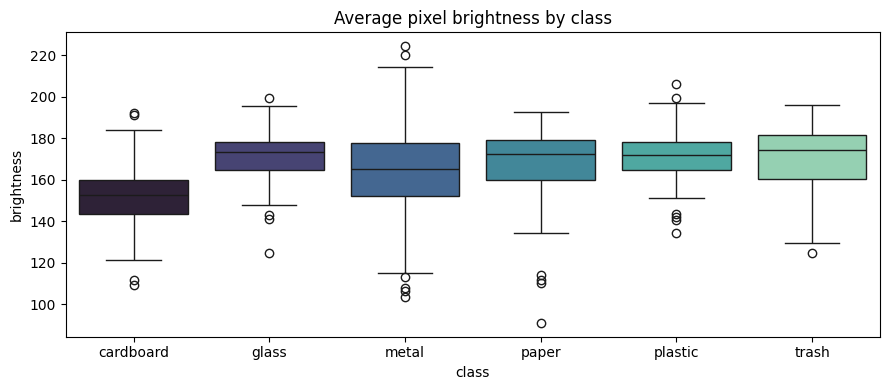

class
glass        171.569291
plastic      171.073987
trash        170.813953
paper        165.627275
metal        163.361971
cardboard    151.282190
Name: brightness, dtype: float64


In [10]:
# Feature 2: brightness distribution per class
from PIL import Image

def sample_brightness(cls, n=60):
    files = list((RAW_DIR / cls).glob("*"))[:n]
    vals = []
    for f in files:
        try:
            img = Image.open(f).convert("L").resize((64, 64))
            vals.append(np.array(img).mean())
        except Exception:
            continue
    return vals

brightness_records = []
for cls in CLASS_NAMES:
    for v in sample_brightness(cls):
        brightness_records.append({"class": cls, "brightness": v})
brightness_df = pd.DataFrame(brightness_records)

plt.figure(figsize=(9, 4))
sns.boxplot(data=brightness_df, x="class", y="brightness", hue="class", palette="mako", legend=False)
plt.title("Average pixel brightness by class")
plt.tight_layout()
    plt.savefig("data/visualizations/brightness.png")
plt.show()

print(brightness_df.groupby("class")["brightness"].mean().sort_values(ascending=False))


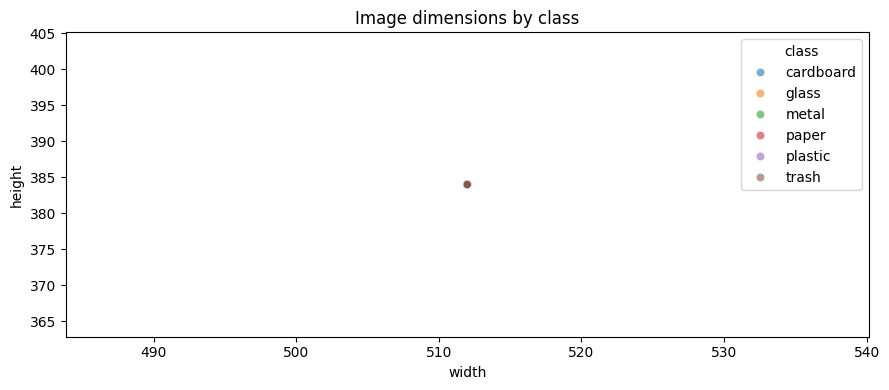

               mean           std
class                            
cardboard  1.333333  2.239184e-16
glass      1.333333  2.239184e-16
metal      1.333333  2.239184e-16
paper      1.333333  2.239184e-16
plastic    1.333333  2.239184e-16
trash      1.333333  2.239184e-16


In [11]:
# Feature 3: image size / aspect ratio distribution
size_records = []
for cls in CLASS_NAMES:
    for f in list((RAW_DIR / cls).glob("*"))[:60]:
        try:
            w, h = Image.open(f).size
            size_records.append({"class": cls, "width": w, "height": h, "aspect": w / h})
        except Exception:
            continue
size_df = pd.DataFrame(size_records)

plt.figure(figsize=(9, 4))
sns.scatterplot(data=size_df, x="width", y="height", hue="class", alpha=0.6)
plt.title("Image dimensions by class")
plt.tight_layout()
    plt.savefig("data/visualizations/dimensions.png")
plt.show()

print(size_df.groupby("class")["aspect"].describe()[["mean", "std"]])


## 4. Preprocessing — train/val/test split + augmentation

In [12]:
def build_train_test_dirs(raw_dir, train_dir, test_dir, test_split=0.15, seed=SEED):
    rng = random.Random(seed)
    for d in (train_dir, test_dir):
        if d.exists():
            shutil.rmtree(d)
        d.mkdir(parents=True)
    for cls in CLASS_NAMES:
        files = list((raw_dir / cls).glob("*"))
        rng.shuffle(files)
        n_test = max(1, int(len(files) * test_split))
        test_files, train_files = files[:n_test], files[n_test:]
        (train_dir / cls).mkdir(parents=True, exist_ok=True)
        (test_dir / cls).mkdir(parents=True, exist_ok=True)
        for f in train_files:
            shutil.copy(f, train_dir / cls / f.name)
        for f in test_files:
            shutil.copy(f, test_dir / cls / f.name)

build_train_test_dirs(RAW_DIR, TRAIN_DIR, TEST_DIR)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    validation_split=0.15,
)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASS_NAMES, subset="training", seed=SEED,
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASS_NAMES, subset="validation", seed=SEED,
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASS_NAMES, shuffle=False,
)


Found 1831 images belonging to 6 classes.
Found 319 images belonging to 6 classes.
Found 377 images belonging to 6 classes.


## 5. Model Creation — MobileNetV2 transfer learning

In [13]:
def build_model(num_classes=len(CLASS_NAMES), img_size=IMG_SIZE, fine_tune_at=None):
    base = MobileNetV2(input_shape=img_size + (3,), include_top=False, weights="imagenet")
    base.trainable = False

    inputs = layers.Input(shape=img_size + (3,))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model, base

model, base_model = build_model()
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Model Training

In [14]:
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_labels), y=y_train_labels
)
class_weight_dict = dict(enumerate(class_weights))

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)


Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 63s 989ms/step - accuracy: 0.5593 - loss: 1.2115 - val_accuracy: 0.6520 - val_loss: 0.8035 - learning_rate: 0.0010
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 79s 946ms/step - accuracy: 0.7428 - loss: 0.7159 - val_accuracy: 0.7994 - val_loss: 0.5978 - learning_rate: 0.0010
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 54s 931ms/step - accuracy: 0.7826 - loss: 0.5910 - val_accuracy: 0.7962 - val_loss: 0.5834 - learning_rate: 0.0010
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 54s 936ms/step - accuracy: 0.8012 - loss: 0.5357 - val_accuracy: 0.7994 - val_loss: 0.5563 - learning_rate: 0.0010
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8132 - loss: 0.5027 - val_accuracy: 0.7649 - val_loss: 0.6202 - learning_rate: 0.0010
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 54s 933ms/step - accuracy: 0.8285 - loss: 0.4620 - val_accuracy: 0.8245 - val_loss: 0.5114 - learning_rate: 0.0010
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 55s 943ms/step - accuracy: 0.8646 - loss: 0.373

In [15]:
# Optional fine-tuning pass: unfreeze the top layers of the base model for a few epochs
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)


Epoch 1/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.7100 - loss: 0.8501 - val_accuracy: 0.8245 - val_loss: 0.4914 - learning_rate: 1.0000e-05
Epoch 2/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7581 - loss: 0.6462 - val_accuracy: 0.8213 - val_loss: 0.5482 - learning_rate: 1.0000e-05
Epoch 3/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8028 - loss: 0.5513 - val_accuracy: 0.8088 - val_loss: 0.5514 - learning_rate: 5.0000e-06
Epoch 4/8
58/58 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.7837 - loss: 0.5672 - val_accuracy: 0.8088 - val_loss: 0.5473 - learning_rate: 5.0000e-06


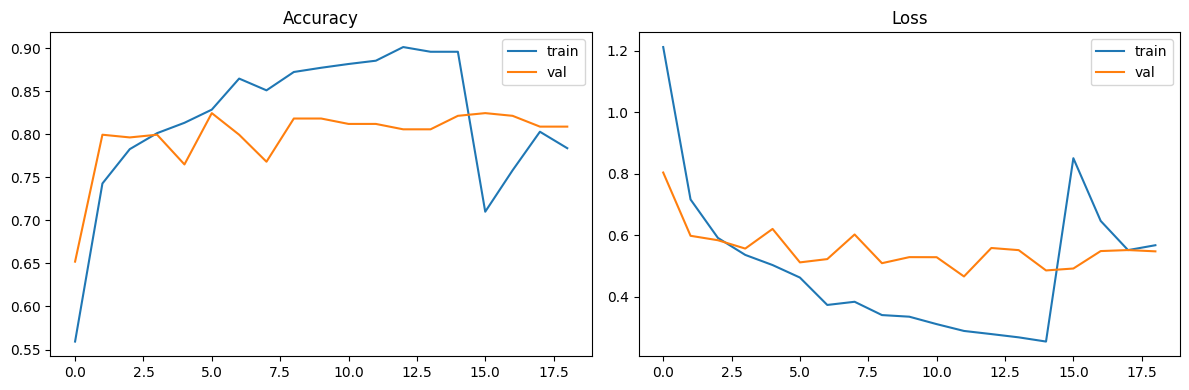

In [16]:
def plot_history(hist, fine_tune_hist=None):
    acc = hist.history["accuracy"]
    val_acc = hist.history["val_accuracy"]
    loss = hist.history["loss"]
    val_loss = hist.history["val_loss"]
    if fine_tune_hist is not None:
        acc += fine_tune_hist.history["accuracy"]
        val_acc += fine_tune_hist.history["val_accuracy"]
        loss += fine_tune_hist.history["loss"]
        val_loss += fine_tune_hist.history["val_loss"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(acc, label="train"); axes[0].plot(val_acc, label="val")
    axes[0].set_title("Accuracy"); axes[0].legend()
    axes[1].plot(loss, label="train"); axes[1].plot(val_loss, label="val")
    axes[1].set_title("Loss"); axes[1].legend()
    plt.tight_layout()
    plt.savefig("data/visualizations/training_history.png")
    plt.show()

plot_history(history, fine_tune_history)


## 7. Evaluation — all required metrics

In [17]:
test_gen.reset()
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average="weighted")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall:    {recall:.4f}")
print(f"Weighted F1:        {f1:.4f}")

try:
    auc = roc_auc_score(
        tf.keras.utils.to_categorical(y_true, num_classes=len(CLASS_NAMES)),
        y_pred_probs, multi_class="ovr",
    )
    print(f"ROC-AUC (OvR):      {auc:.4f}")
except ValueError as e:
    print("ROC-AUC could not be computed:", e)

test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")


12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 801ms/step
=== Classification Report ===
              precision    recall  f1-score   support

   cardboard       0.84      0.88      0.86        60
       glass       0.88      0.79      0.83        75
       metal       0.78      0.85      0.81        61
       paper       0.83      0.85      0.84        89
     plastic       0.86      0.85      0.85        72
       trash       0.53      0.45      0.49        20

    accuracy                           0.82       377
   macro avg       0.79      0.78      0.78       377
weighted avg       0.82      0.82      0.82       377

Weighted Precision: 0.8218
Weighted Recall:    0.8223
Weighted F1:        0.8209
ROC-AUC (OvR):      0.9665
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 549ms/step - accuracy: 0.8223 - loss: 0.5178

Test Loss: 0.5178 | Test Accuracy: 0.8223


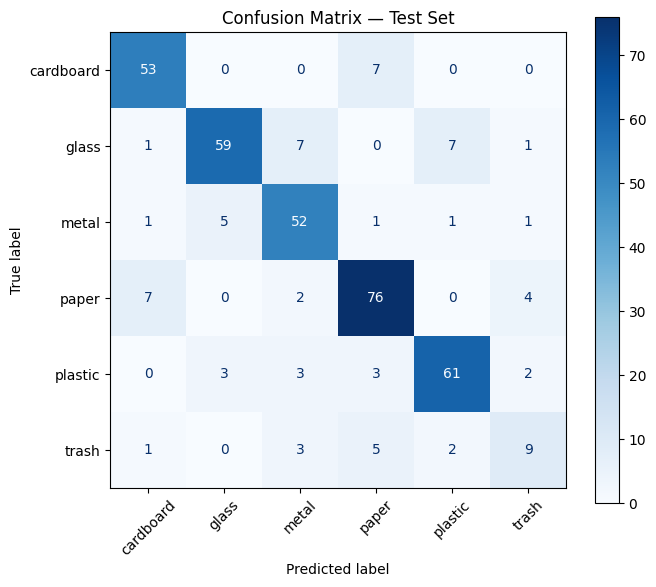

In [18]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
    plt.savefig("data/visualizations/confusion_matrix.png")
plt.show()


## 8. Save the model

In [19]:
MODEL_PATH = MODEL_DIR / "garbage_classifier_v1.h5"
model.save(MODEL_PATH)
print("Saved model to", MODEL_PATH)


Saved model to ../models/garbage_classifier_v1.h5


## 9. Retraining function

A single reusable function the API's `/retrain` endpoint calls. It takes a directory
of newly uploaded, labeled images (one subfolder per class, merged into `TRAIN_DIR`
beforehand by the upload endpoint), retrains from the current saved model, evaluates
on the held-out test set, and only overwrites the deployed model file if the new
version's weighted F1 improves on (or stays within tolerance of) the previous one —
this is the retraining "trigger" logic reused by the API.


In [20]:
def retrain_model(existing_model_path=MODEL_PATH, train_dir=TRAIN_DIR, test_dir=TEST_DIR,
                   epochs=6, min_f1_improvement=-0.01):
    """Retrain from the currently saved model on the current TRAIN_DIR contents.

    Returns (new_model_path, metrics_dict, was_deployed: bool).
    was_deployed is False if the retrained model's weighted F1 regressed by more
    than `min_f1_improvement` versus the previous model on the test set.
    """
    current_model = tf.keras.models.load_model(existing_model_path)

    train_gen_r = train_datagen.flow_from_directory(
        train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", classes=CLASS_NAMES, subset="training", seed=SEED,
    )
    val_gen_r = train_datagen.flow_from_directory(
        train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", classes=CLASS_NAMES, subset="validation", seed=SEED,
    )
    test_gen_r = test_datagen.flow_from_directory(
        test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode="categorical", classes=CLASS_NAMES, shuffle=False,
    )

    # Baseline F1 with the currently deployed model
    baseline_pred = np.argmax(current_model.predict(test_gen_r), axis=1)
    _, _, baseline_f1, _ = precision_recall_fscore_support(
        test_gen_r.classes, baseline_pred, average="weighted"
    )

    current_model.fit(
        train_gen_r, validation_data=val_gen_r, epochs=epochs,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
    )

    new_pred = np.argmax(current_model.predict(test_gen_r), axis=1)
    precision, recall, new_f1, _ = precision_recall_fscore_support(
        test_gen_r.classes, new_pred, average="weighted"
    )
    metrics = {"baseline_f1": baseline_f1, "new_f1": new_f1, "precision": precision, "recall": recall}

    was_deployed = (new_f1 - baseline_f1) >= min_f1_improvement
    if was_deployed:
        current_model.save(existing_model_path)

    return existing_model_path, metrics, was_deployed

# Example call (run once new labeled data has been placed under TRAIN_DIR by the upload endpoint):
# path, metrics, deployed = retrain_model()
# print(metrics, "deployed:", deployed)
